<a href="https://colab.research.google.com/github/MONIKAMONI24/Mavenprgm2/blob/master/Intership_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# -------------------------------
# 1. Import Libraries
# -------------------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


In [2]:
# -------------------------------
# 2. Upload Dataset
# -------------------------------
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("customer_churn_data.csv")

print(df.head())
print(df.info())
print(df['Churn'].value_counts())   # assuming target column is 'Churn'


Saving customer_churn_data.csv to customer_churn_data (1).csv
  customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0   CUST0000    Male              0      No        Yes      23           No   
1   CUST0001  Female              0     Yes         No      43           No   
2   CUST0002    Male              1      No         No      51          Yes   
3   CUST0003    Male              1      No         No      72          Yes   
4   CUST0004    Male              1      No         No      25          Yes   

      MultipleLines InternetService       OnlineSecurity  ...  \
0  No phone service              No  No internet service  ...   
1  No phone service             DSL                  Yes  ...   
2                No             DSL                   No  ...   
3               Yes             DSL                  Yes  ...   
4               Yes             DSL                   No  ...   

      DeviceProtection          TechSupport          StreamingTV  \
0  N

In [3]:
# -------------------------------
# 3. Preprocessing
# -------------------------------
# Encode categorical variables
for col in df.select_dtypes(include=['object']).columns:
    if col != 'Churn':
        df[col] = LabelEncoder().fit_transform(df[col])

# Encode target
df['Churn'] = df['Churn'].map({'No':0, 'Yes':1}).astype(int)

# Features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [4]:
# -------------------------------
# 4. Models
# -------------------------------
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)
# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# XGBoost
xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Neural Network
nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = nn_model.fit(X_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)
y_pred_nn = (nn_model.predict(X_test_scaled) >= 0.5).astype(int).flatten()


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:36:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5023 - loss: 0.7078 - val_accuracy: 0.5069 - val_loss: 0.6984
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5283 - loss: 0.6921 - val_accuracy: 0.5165 - val_loss: 0.6965
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5456 - loss: 0.6890 - val_accuracy: 0.5133 - val_loss: 0.6971
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5501 - loss: 0.6851 - val_accuracy: 0.5197 - val_loss: 0.7025
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5597 - loss: 0.6817 - val_accuracy: 0.5101 - val_loss: 0.6970
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5644 - loss: 0.6786 - val_accuracy: 0.5207 - val_loss: 0.6992
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5897 - loss: 0.6723 - val_accuracy: 0.5101 - val_loss: 0.7030
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5865 - loss: 0.6709 - val_accuracy: 0

In [5]:
# -------------------------------
# 5. Evaluation
# -------------------------------
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f"{name} -> Accuracy: {acc:.2f}")
    print(classification_report(y_true, y_pred))

evaluate_model("Logistic Regression", y_test, y_pred_log)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb)
evaluate_model("Neural Network", y_test, y_pred_nn)


Logistic Regression -> Accuracy: 0.49
              precision    recall  f1-score   support

           0       0.49      0.63      0.55       584
           1       0.49      0.35      0.41       592

    accuracy                           0.49      1176
   macro avg       0.49      0.49      0.48      1176
weighted avg       0.49      0.49      0.48      1176

Random Forest -> Accuracy: 0.48
              precision    recall  f1-score   support

           0       0.48      0.54      0.51       584
           1       0.48      0.42      0.45       592

    accuracy                           0.48      1176
   macro avg       0.48      0.48      0.48      1176
weighted avg       0.48      0.48      0.48      1176

XGBoost -> Accuracy: 0.49
              precision    recall  f1-score   support

           0       0.49      0.54      0.52       584
           1       0.50      0.45      0.47       592

    accuracy                           0.49      1176
   macro avg       0.49      0.4

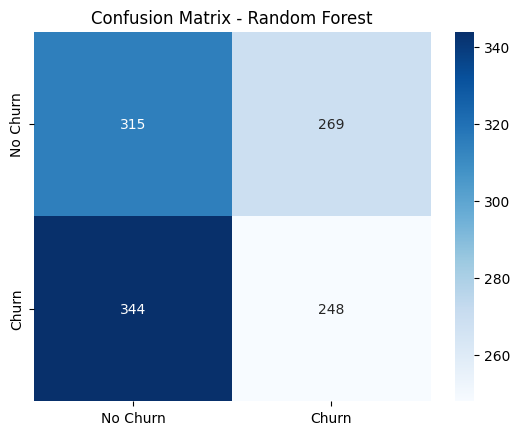

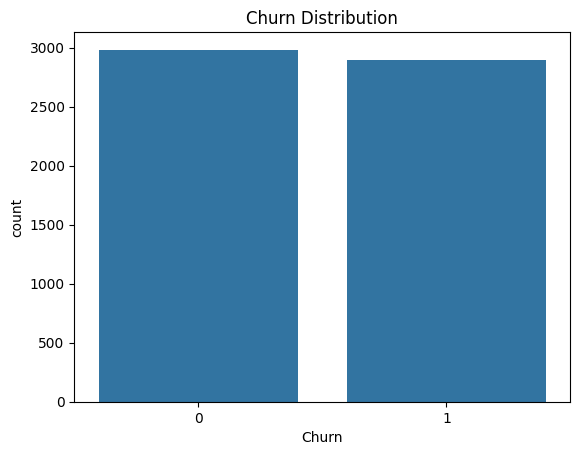

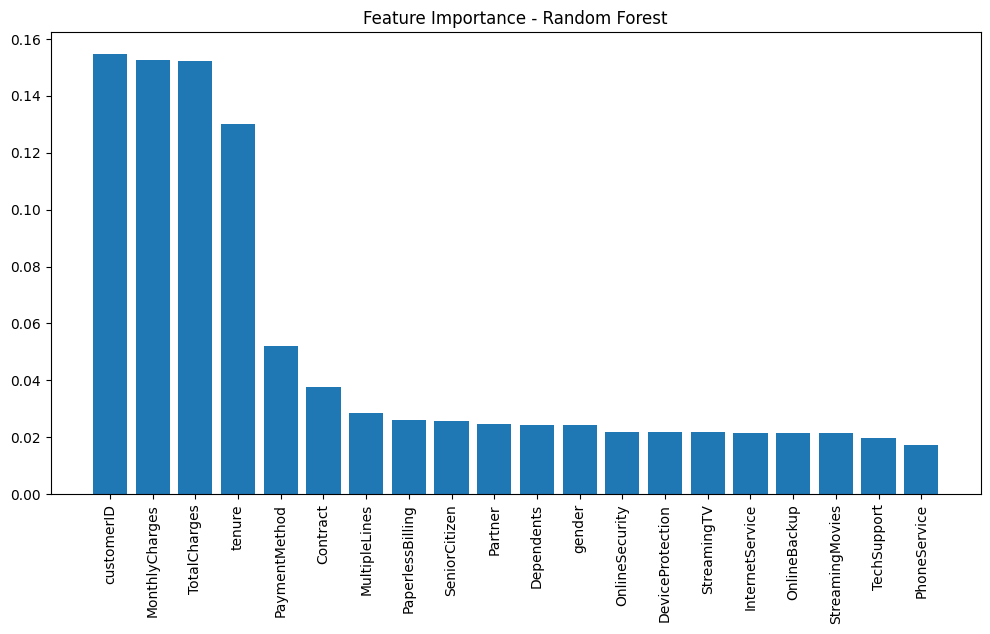

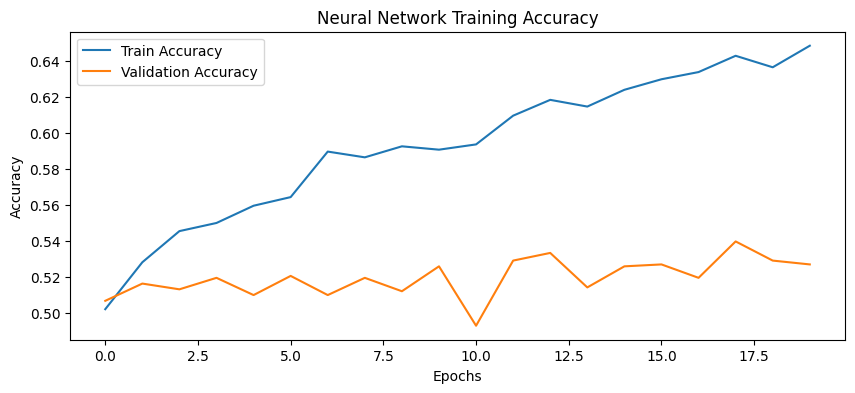

In [6]:
# -------------------------------
# 6. Visualizations
# -------------------------------
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["No Churn","Churn"], yticklabels=["No Churn","Churn"])
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Churn distribution
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

# Feature importance (Random Forest)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12,6))
plt.title("Feature Importance - Random Forest")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.show()

# Neural Network training curves
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Neural Network Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [7]:
# -------------------------------
# 7. Export Predictions for Tableau/Power BI
# -------------------------------
results = pd.DataFrame({
    "Actual": y_test,
    "LogReg_Pred": y_pred_log,
    "RandomForest_Pred": y_pred_rf,
    "XGBoost_Pred": y_pred_xgb,
    "NeuralNetwork_Pred": y_pred_nn
})

results.to_csv("customer_churn_predictions.csv", index=False)

from google.colab import files
files.download("customer_churn_predictions.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
# -------------------------------
# 8. Real-Time Prediction Function
# -------------------------------
def predict_churn(features_dict):
    input_df = pd.DataFrame([features_dict])
    input_df = input_df.reindex(columns=X.columns, fill_value=0)
    input_scaled = scaler.transform(input_df)

    pred_log = log_model.predict(input_scaled)[0]
    pred_rf = rf_model.predict(input_df)[0]
    pred_xgb = xgb_model.predict(input_df)[0]
    pred_nn = (nn_model.predict(input_scaled) >= 0.5).astype(int)[0][0]

    return {
        "Logistic Regression": "Churn" if pred_log==1 else "No Churn",
        "Random Forest": "Churn" if pred_rf==1 else "No Churn",
        "XGBoost": "Churn" if pred_xgb==1 else "No Churn",
        "Neural Network": "Churn" if pred_nn==1 else "No Churn"
    }


In [9]:
# Example usage
sample_features = {
    "tenure": 12,
    "MonthlyCharges": 70,
    "TotalCharges": 800,
    "Contract": 1,  # encoded categorical
    "InternetService": 2,  # encoded categorical
    "PaymentMethod": 3     # encoded categorical
}
print("Predicted Churn:", predict_churn(sample_features))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted Churn: {'Logistic Regression': 'Churn', 'Random Forest': 'No Churn', 'XGBoost': 'No Churn', 'Neural Network': 'No Churn'}
